# Credit Score Predictor — Exploratory Data Analysis
## 25 Visualizations on Comprehensive Loan Data

This notebook performs end-to-end EDA on `comprehensive_loan_data.csv`, covering univariate, bivariate, correlation, and multivariate analyses across all features.

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Load data
df = pd.read_csv("comprehensive_loan_data.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 10)


,Age,Monthly_Income,Credit_Score,Loan_Amount_Requested,Employment_Status,Existing_Debts,Number_of_Previous_Loans,Payment_History,Debt_to_Income_Ratio,Repayment_Status
0,56,6209,365,26154,Employed,7941,2,Good,0.64,0
1,69,6007,432,8240,Employed,10712,7,Poor,0.58,0
2,46,8075,665,40612,Employed,12296,7,Good,0.58,1
3,32,6273,381,2585,Employed,10899,3,Fair,0.14,0
4,60,13946,627,11541,Employed,6168,0,Good,0.22,1


## 2. Basic Data Inspection

In [2]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Descriptive Statistics ===")
display(df.describe(include="all"))

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicate Rows ===")
print(f"Total duplicates: {df.duplicated().sum()}")

=== Shape ===
(10000, 10)

=== Data Types ===
Age                           int64
Monthly_Income                int64
Credit_Score                  int64
Loan_Amount_Requested         int64
Employment_Status               str
Existing_Debts                int64
Number_of_Previous_Loans      int64
Payment_History                 str
Debt_to_Income_Ratio        float64
Repayment_Status              int64
dtype: object

=== Descriptive Statistics ===


,Age,Monthly_Income,Credit_Score,Loan_Amount_Requested,Employment_Status,Existing_Debts,Number_of_Previous_Loans,Payment_History,Debt_to_Income_Ratio,Repayment_Status
count,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000,10000.000000,10000.000000
unique,NaN,NaN,NaN,NaN,4,NaN,NaN,4,NaN,NaN
top,NaN,NaN,NaN,NaN,Employed,NaN,NaN,Good,NaN,NaN
freq,NaN,NaN,NaN,NaN,7055,NaN,NaN,4014,NaN,NaN
mean,46.166100,10818.445900,576.042000,25289.373100,NaN,7450.058000,4.455500,NaN,0.376022,0.698000
std,16.421738,5377.375441,159.152091,14142.688073,NaN,4343.785241,2.869502,NaN,0.186317,0.459148
min,18.000000,1502.000000,300.000000,1001.000000,NaN,2.000000,0.000000,NaN,0.050000,0.000000
25%,32.000000,6167.500000,437.000000,13096.750000,NaN,3699.500000,2.000000,NaN,0.210000,0.000000
50%,46.000000,10862.000000,576.500000,25138.500000,NaN,7450.500000,4.000000,NaN,0.380000,1.000000
75%,61.000000,15465.500000,713.000000,37542.250000,NaN,11203.000000,7.000000,NaN,0.540000,1.000000



=== Missing Values ===
Age                         0
Monthly_Income              0
Credit_Score                0
Loan_Amount_Requested       0
Employment_Status           0
Existing_Debts              0
Number_of_Previous_Loans    0
Payment_History             0
Debt_to_Income_Ratio        0
Repayment_Status            0
dtype: int64

=== Duplicate Rows ===
Total duplicates: 0


Key findings: Credit_Score (r=0.42) and Monthly_Income (r=0.30) are the strongest positive predictors of repayment; Payment_History negatively correlates (r=−0.29); Poor payment history leads to an 82.6% default rate vs 21.6% for Good.

## 3. Data Cleaning and Preprocessing

In [3]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Keep a raw copy for categorical plots
df_raw = df.copy()

# Encode categorical columns
le = LabelEncoder()
df["Employment_Status_enc"] = le.fit_transform(df["Employment_Status"])
df["Payment_History_enc"] = le.fit_transform(df["Payment_History"])

# Verify value counts
print("Employment_Status unique values:", df["Employment_Status"].unique())
print("Payment_History unique values:", df["Payment_History"].unique())
print("Repayment_Status value counts:\n", df["Repayment_Status"].value_counts())
print("\nCleaned dataset shape:", df.shape)

Employment_Status unique values: <StringArray>
['Employed', 'Self-Employed', 'Student', 'Unemployed']
Length: 4, dtype: str
Payment_History unique values: <StringArray>
['Good', 'Poor', 'Fair', 'Excellent']
Length: 4, dtype: str
Repayment_Status value counts:
 Repayment_Status
1    6980
0    3020
Name: count, dtype: int64

Cleaned dataset shape: (10000, 12)


## 4. Univariate Analysis – Numerical Features
**Visualizations 1–6**

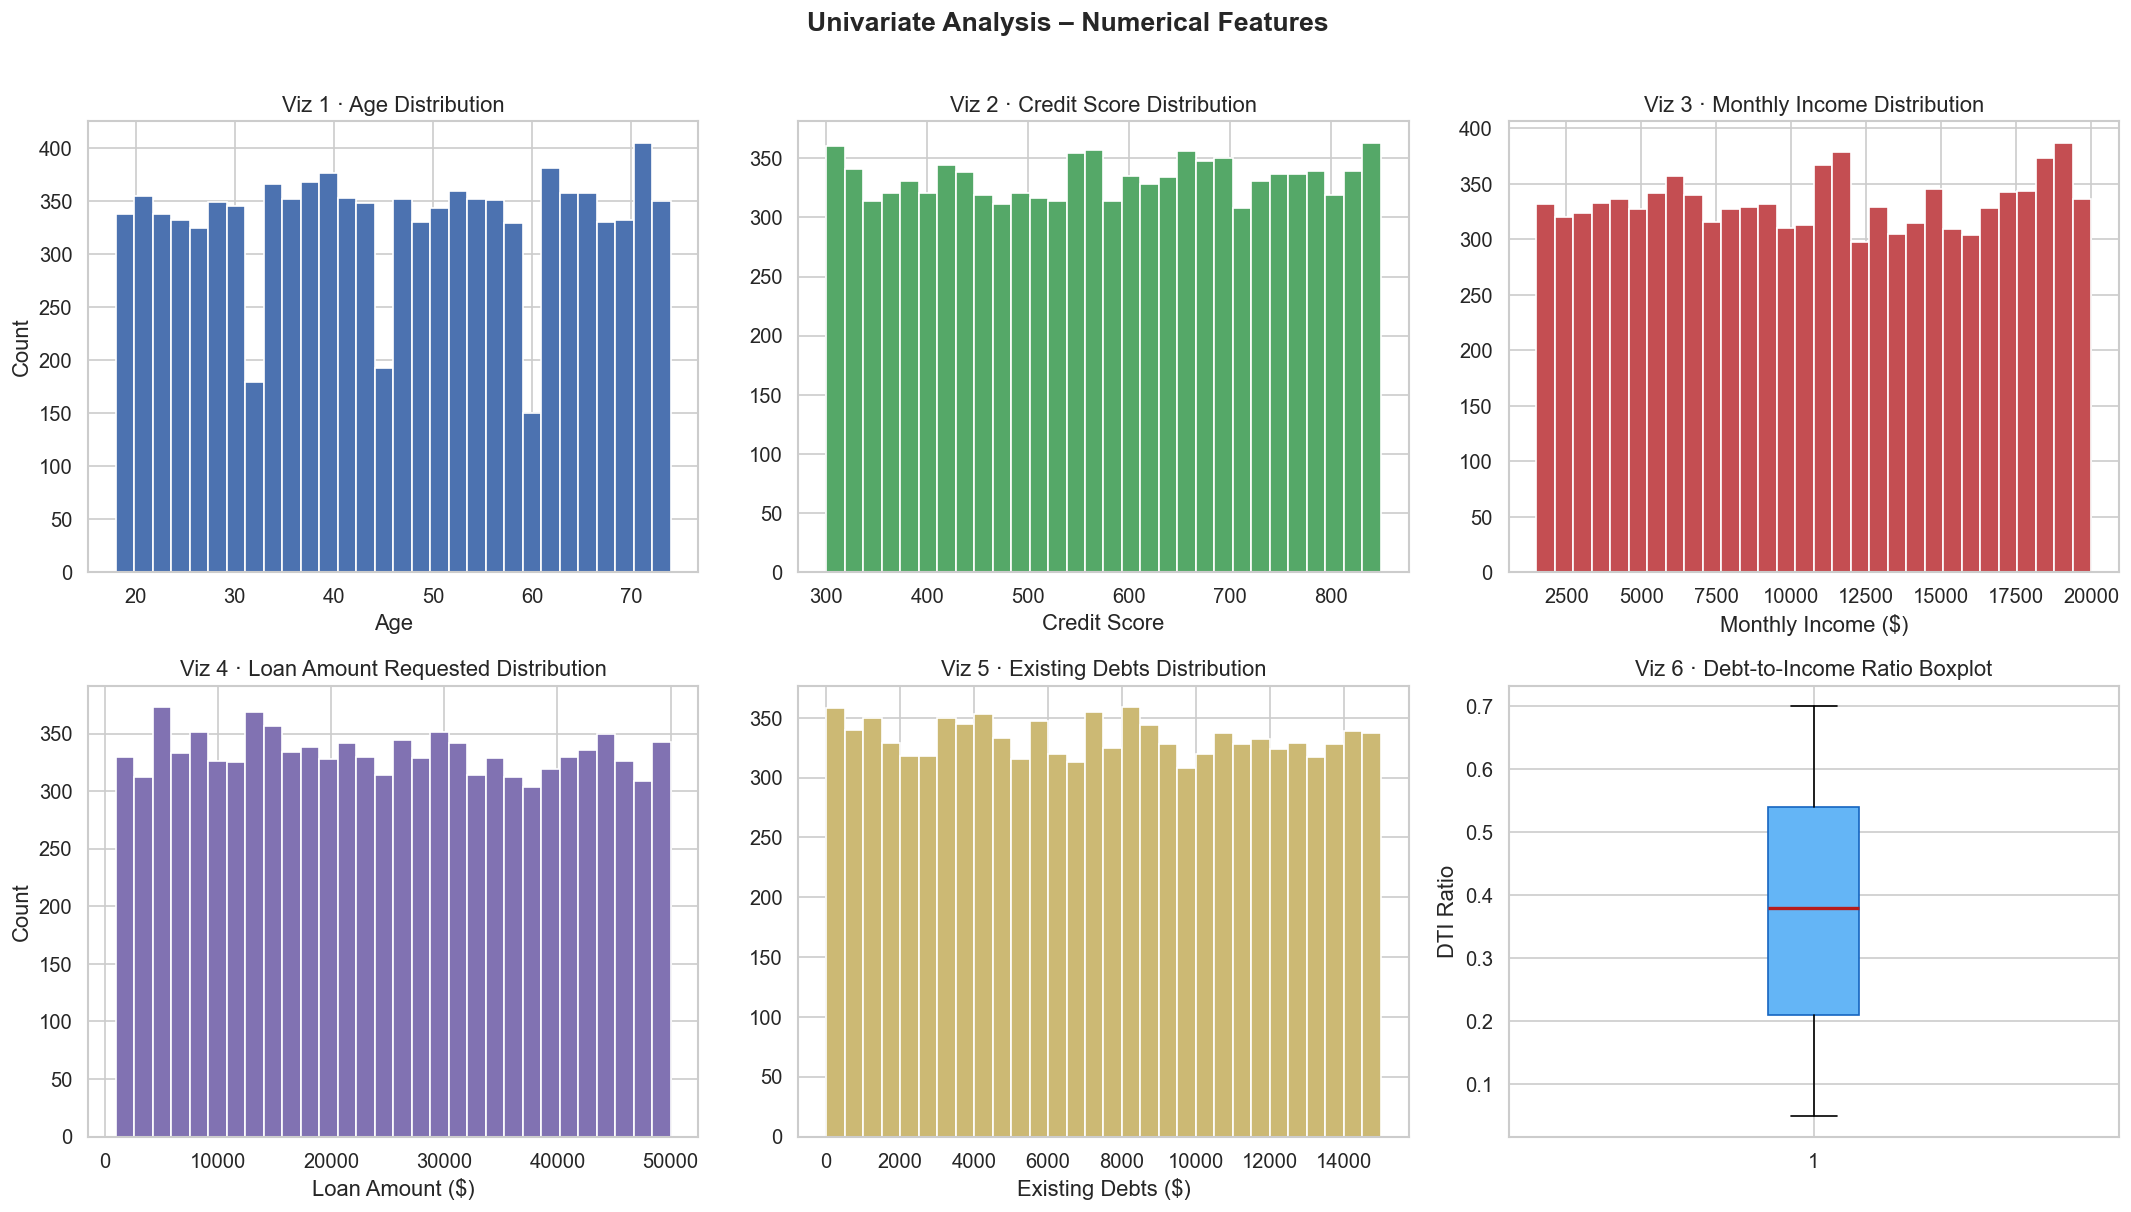

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Univariate Analysis – Numerical Features", fontsize=16, fontweight="bold", y=1.01)

# Viz 1 – Age histogram
axes[0, 0].hist(df["Age"], bins=30, color="#4C72B0", edgecolor="white")
axes[0, 0].set_title("Viz 1 · Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

# Viz 2 – Credit_Score histogram
axes[0, 1].hist(df["Credit_Score"], bins=30, color="#55A868", edgecolor="white")
axes[0, 1].set_title("Viz 2 · Credit Score Distribution")
axes[0, 1].set_xlabel("Credit Score")

# Viz 3 – Monthly_Income histogram
axes[0, 2].hist(df["Monthly_Income"], bins=30, color="#C44E52", edgecolor="white")
axes[0, 2].set_title("Viz 3 · Monthly Income Distribution")
axes[0, 2].set_xlabel("Monthly Income ($)")

# Viz 4 – Loan_Amount_Requested histogram
axes[1, 0].hist(df["Loan_Amount_Requested"], bins=30, color="#8172B2", edgecolor="white")
axes[1, 0].set_title("Viz 4 · Loan Amount Requested Distribution")
axes[1, 0].set_xlabel("Loan Amount ($)")
axes[1, 0].set_ylabel("Count")

# Viz 5 – Existing_Debts histogram
axes[1, 1].hist(df["Existing_Debts"], bins=30, color="#CCB974", edgecolor="white")
axes[1, 1].set_title("Viz 5 · Existing Debts Distribution")
axes[1, 1].set_xlabel("Existing Debts ($)")

# Viz 6 – Debt_to_Income_Ratio boxplot
axes[1, 2].boxplot(df["Debt_to_Income_Ratio"].dropna(), patch_artist=True,
                   boxprops=dict(facecolor="#64B5F6", color="#1565C0"),
                   medianprops=dict(color="#B71C1C", linewidth=2))
axes[1, 2].set_title("Viz 6 · Debt-to-Income Ratio Boxplot")
axes[1, 2].set_ylabel("DTI Ratio")

plt.tight_layout()
plt.show()

## 5. Univariate Analysis – Categorical Features
**Visualizations 7–10**

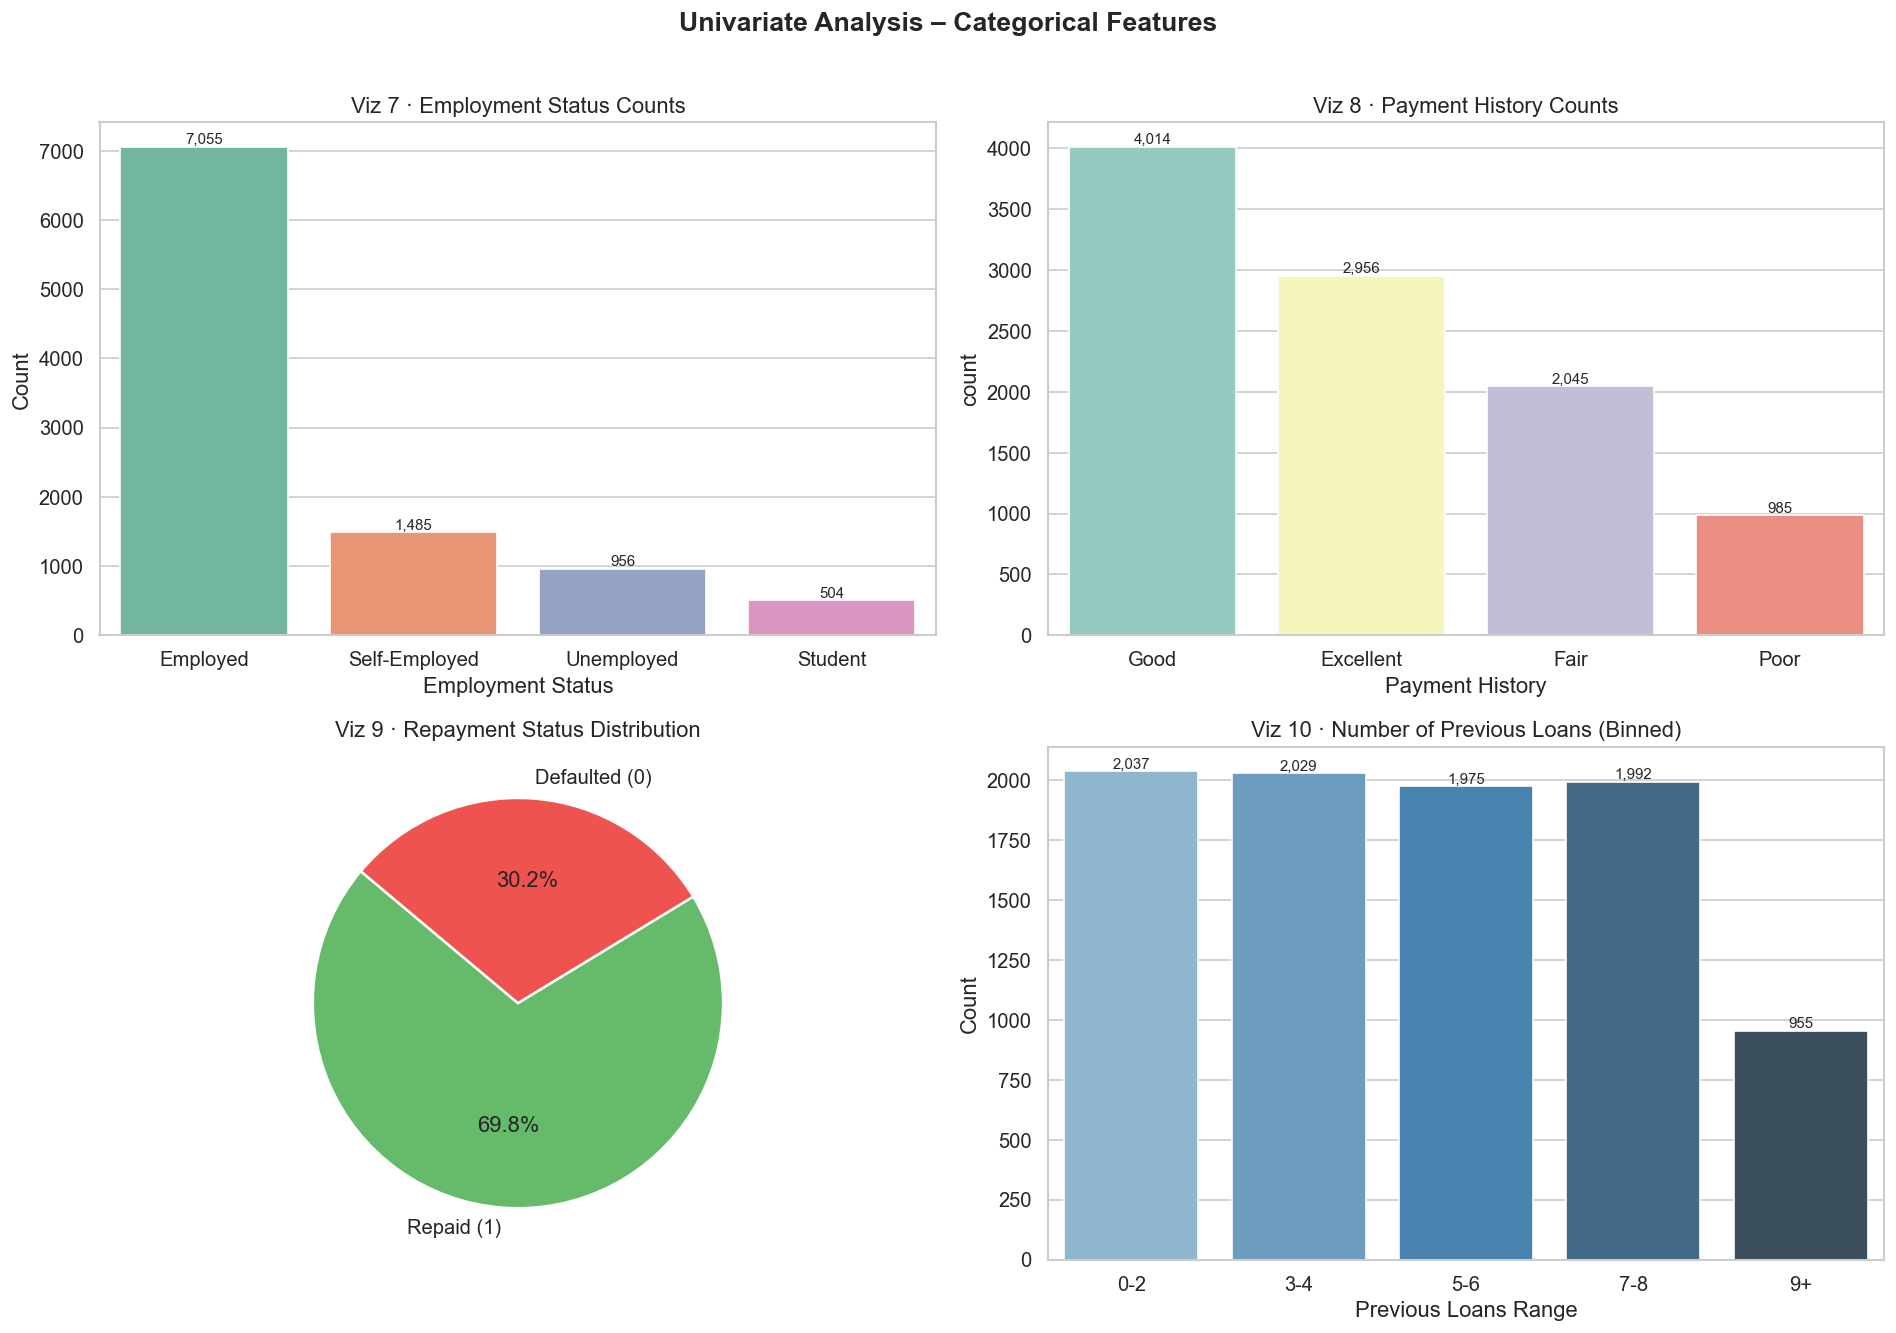

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Univariate Analysis – Categorical Features", fontsize=16, fontweight="bold", y=1.01)

# Viz 7 – Employment_Status countplot
emp_order = df_raw["Employment_Status"].value_counts().index
sns.countplot(data=df_raw, x="Employment_Status", order=emp_order,
              palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Viz 7 · Employment Status Counts")
axes[0, 0].set_xlabel("Employment Status")
axes[0, 0].set_ylabel("Count")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

# Viz 8 – Payment_History countplot
ph_order = df_raw["Payment_History"].value_counts().index
sns.countplot(data=df_raw, x="Payment_History", order=ph_order,
              palette="Set3", ax=axes[0, 1])
axes[0, 1].set_title("Viz 8 · Payment History Counts")
axes[0, 1].set_xlabel("Payment History")
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

# Viz 9 – Repayment_Status pie chart
repay_counts = df_raw["Repayment_Status"].value_counts()
labels = ["Repaid (1)" if i == 1 else "Defaulted (0)" for i in repay_counts.index]
axes[1, 0].pie(repay_counts, labels=labels, autopct="%1.1f%%",
               colors=["#66BB6A", "#EF5350"], startangle=140,
               wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1, 0].set_title("Viz 9 · Repayment Status Distribution")

# Viz 10 – Number_of_Previous_Loans binned countplot
bins = [0, 2, 4, 6, 8, df_raw["Number_of_Previous_Loans"].max() + 1]
labels_bins = ["0-2", "3-4", "5-6", "7-8", "9+"]
df_raw["Loan_Bin"] = pd.cut(df_raw["Number_of_Previous_Loans"], bins=bins, labels=labels_bins, right=True)
sns.countplot(data=df_raw, x="Loan_Bin", palette="Blues_d", ax=axes[1, 1])
axes[1, 1].set_title("Viz 10 · Number of Previous Loans (Binned)")
axes[1, 1].set_xlabel("Previous Loans Range")
axes[1, 1].set_ylabel("Count")
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 6. Bivariate Analysis – Numerical Features vs Target
**Visualizations 11–15**

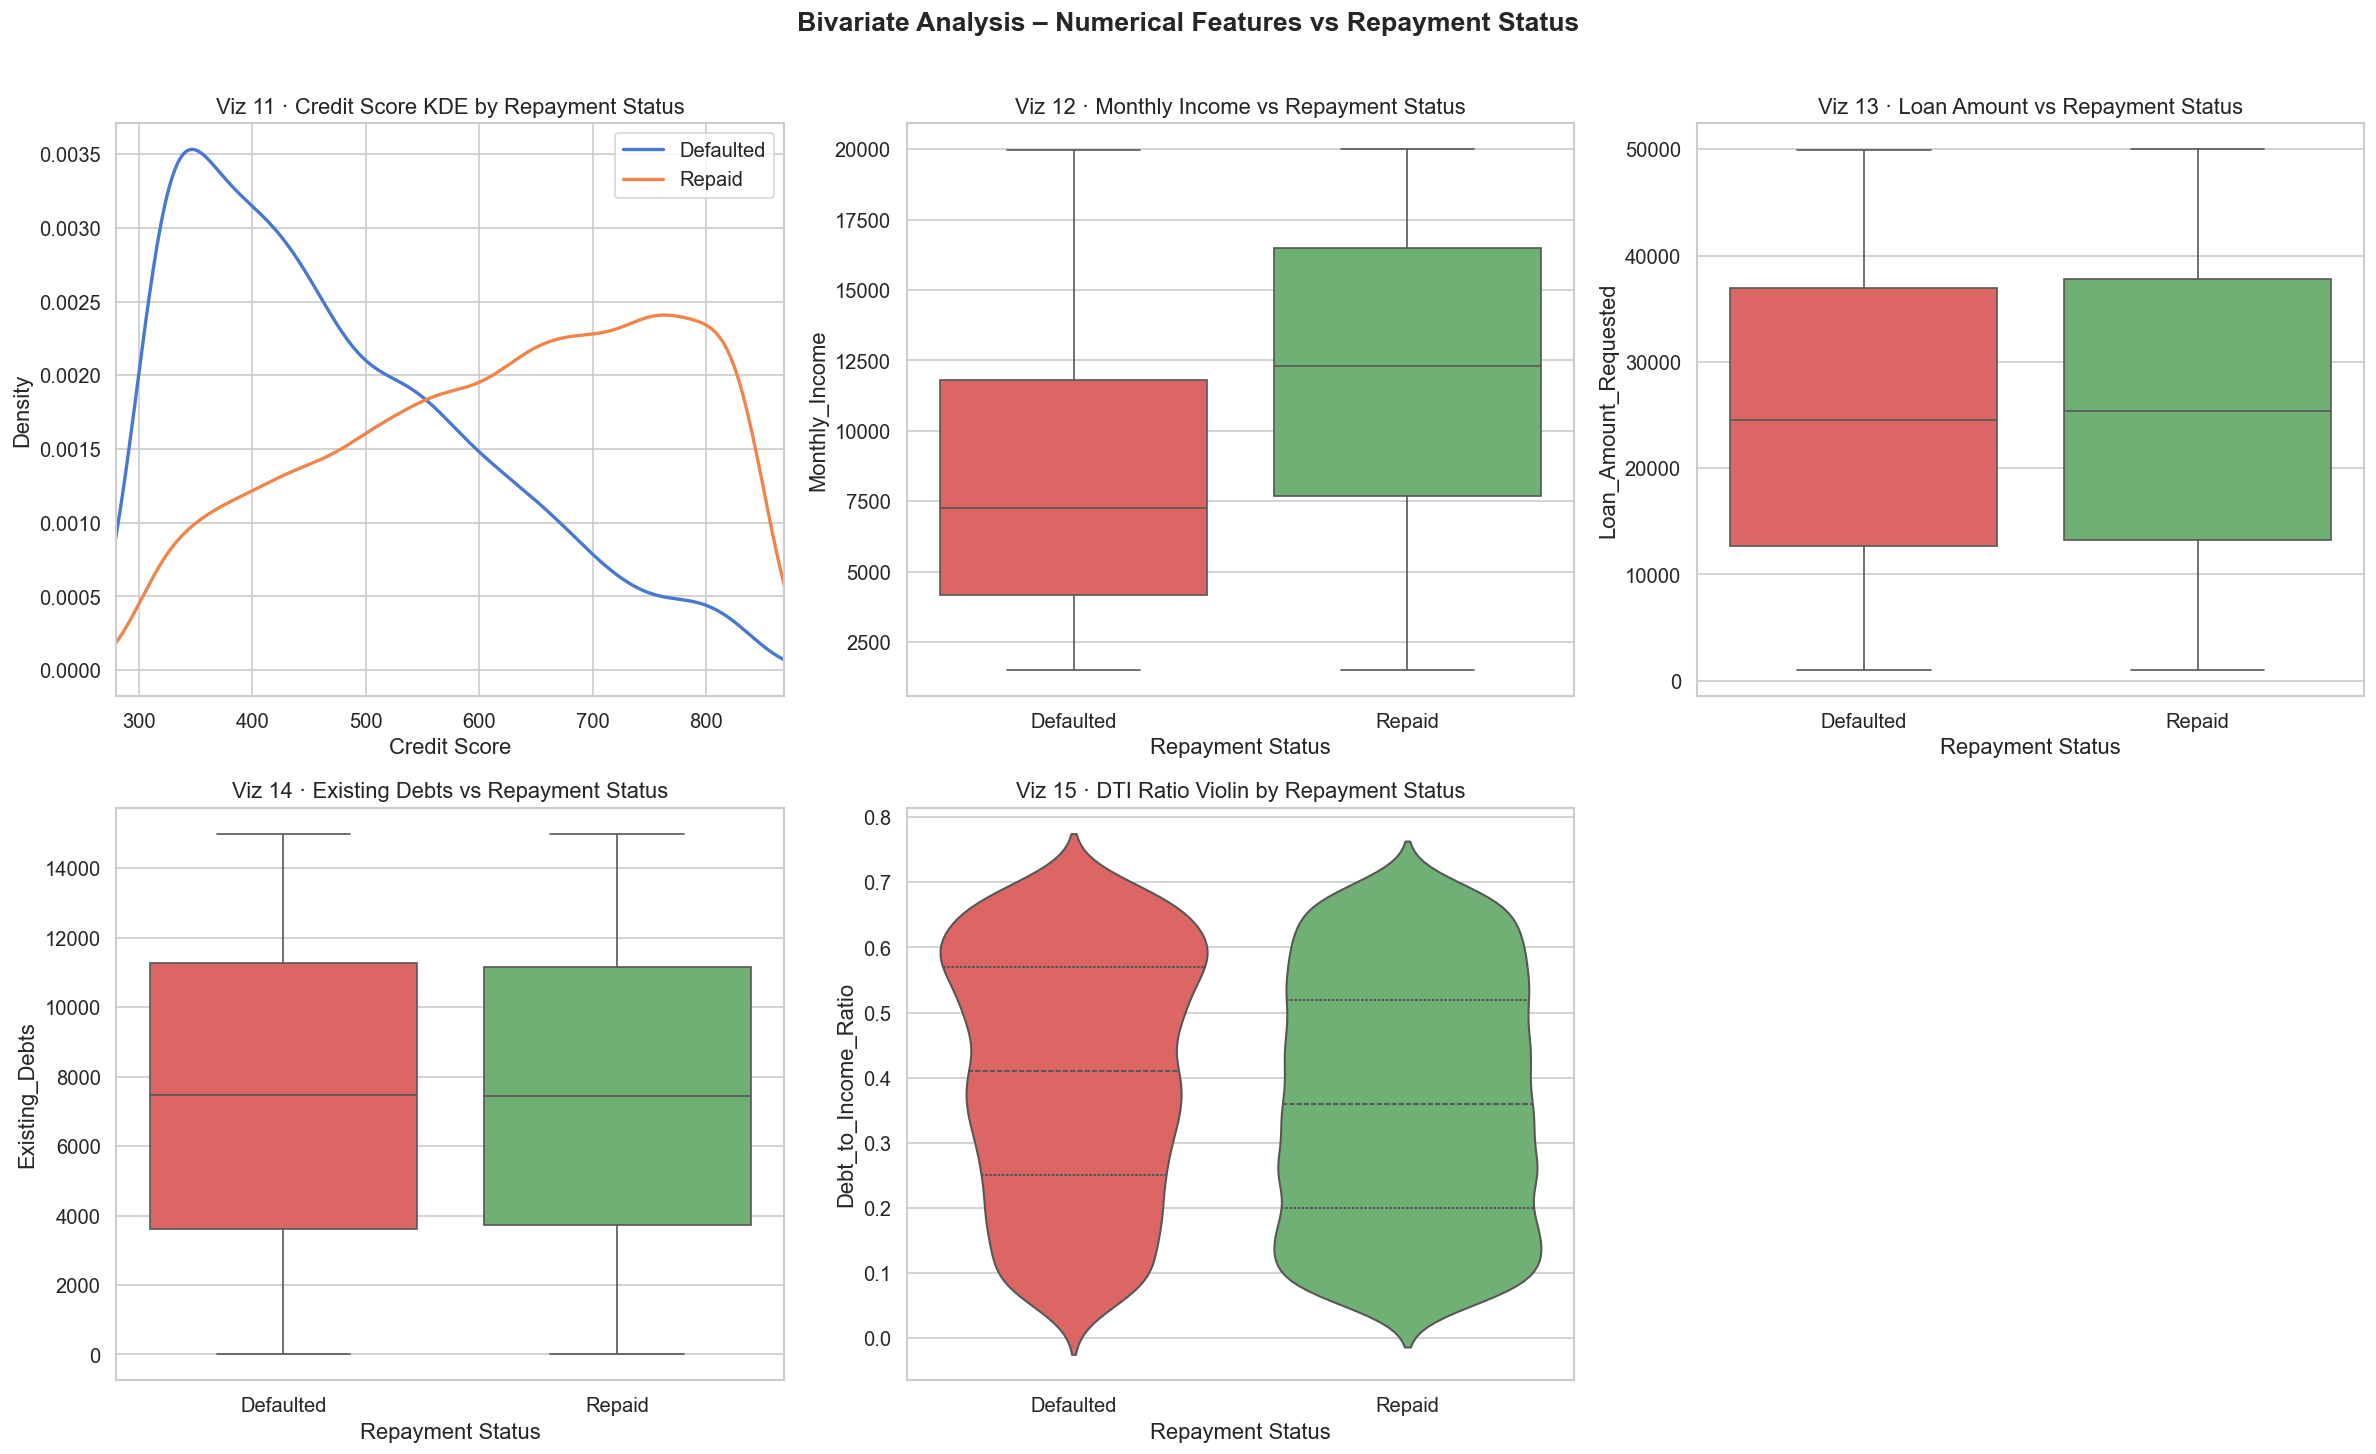

In [6]:
df_raw["Repayment_Label"] = df_raw["Repayment_Status"].map({0: "Defaulted", 1: "Repaid"})

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Bivariate Analysis – Numerical Features vs Repayment Status",
             fontsize=16, fontweight="bold", y=1.01)

# Viz 11 – KDE: Credit_Score by Repayment_Status
for label, grp in df_raw.groupby("Repayment_Label"):
    grp["Credit_Score"].plot.kde(ax=axes[0, 0], label=label, linewidth=2)
axes[0, 0].set_title("Viz 11 · Credit Score KDE by Repayment Status")
axes[0, 0].set_xlabel("Credit Score")
axes[0, 0].legend()
axes[0, 0].set_xlim(df_raw["Credit_Score"].min() - 20, df_raw["Credit_Score"].max() + 20)

# Viz 12 – Boxplot: Monthly_Income vs Repayment_Status
sns.boxplot(data=df_raw, x="Repayment_Label", y="Monthly_Income",
            palette={"Defaulted": "#EF5350", "Repaid": "#66BB6A"}, ax=axes[0, 1])
axes[0, 1].set_title("Viz 12 · Monthly Income vs Repayment Status")
axes[0, 1].set_xlabel("Repayment Status")

# Viz 13 – Boxplot: Loan_Amount_Requested vs Repayment_Status
sns.boxplot(data=df_raw, x="Repayment_Label", y="Loan_Amount_Requested",
            palette={"Defaulted": "#EF5350", "Repaid": "#66BB6A"}, ax=axes[0, 2])
axes[0, 2].set_title("Viz 13 · Loan Amount vs Repayment Status")
axes[0, 2].set_xlabel("Repayment Status")

# Viz 14 – Boxplot: Existing_Debts vs Repayment_Status
sns.boxplot(data=df_raw, x="Repayment_Label", y="Existing_Debts",
            palette={"Defaulted": "#EF5350", "Repaid": "#66BB6A"}, ax=axes[1, 0])
axes[1, 0].set_title("Viz 14 · Existing Debts vs Repayment Status")
axes[1, 0].set_xlabel("Repayment Status")

# Viz 15 – Violin: Debt_to_Income_Ratio vs Repayment_Status
sns.violinplot(data=df_raw, x="Repayment_Label", y="Debt_to_Income_Ratio",
               palette={"Defaulted": "#EF5350", "Repaid": "#66BB6A"},
               inner="quartile", ax=axes[1, 1])
axes[1, 1].set_title("Viz 15 · DTI Ratio Violin by Repayment Status")
axes[1, 1].set_xlabel("Repayment Status")

# Hide the unused subplot
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

## 7. Bivariate Analysis – Categorical Features vs Target
**Visualizations 16–19**

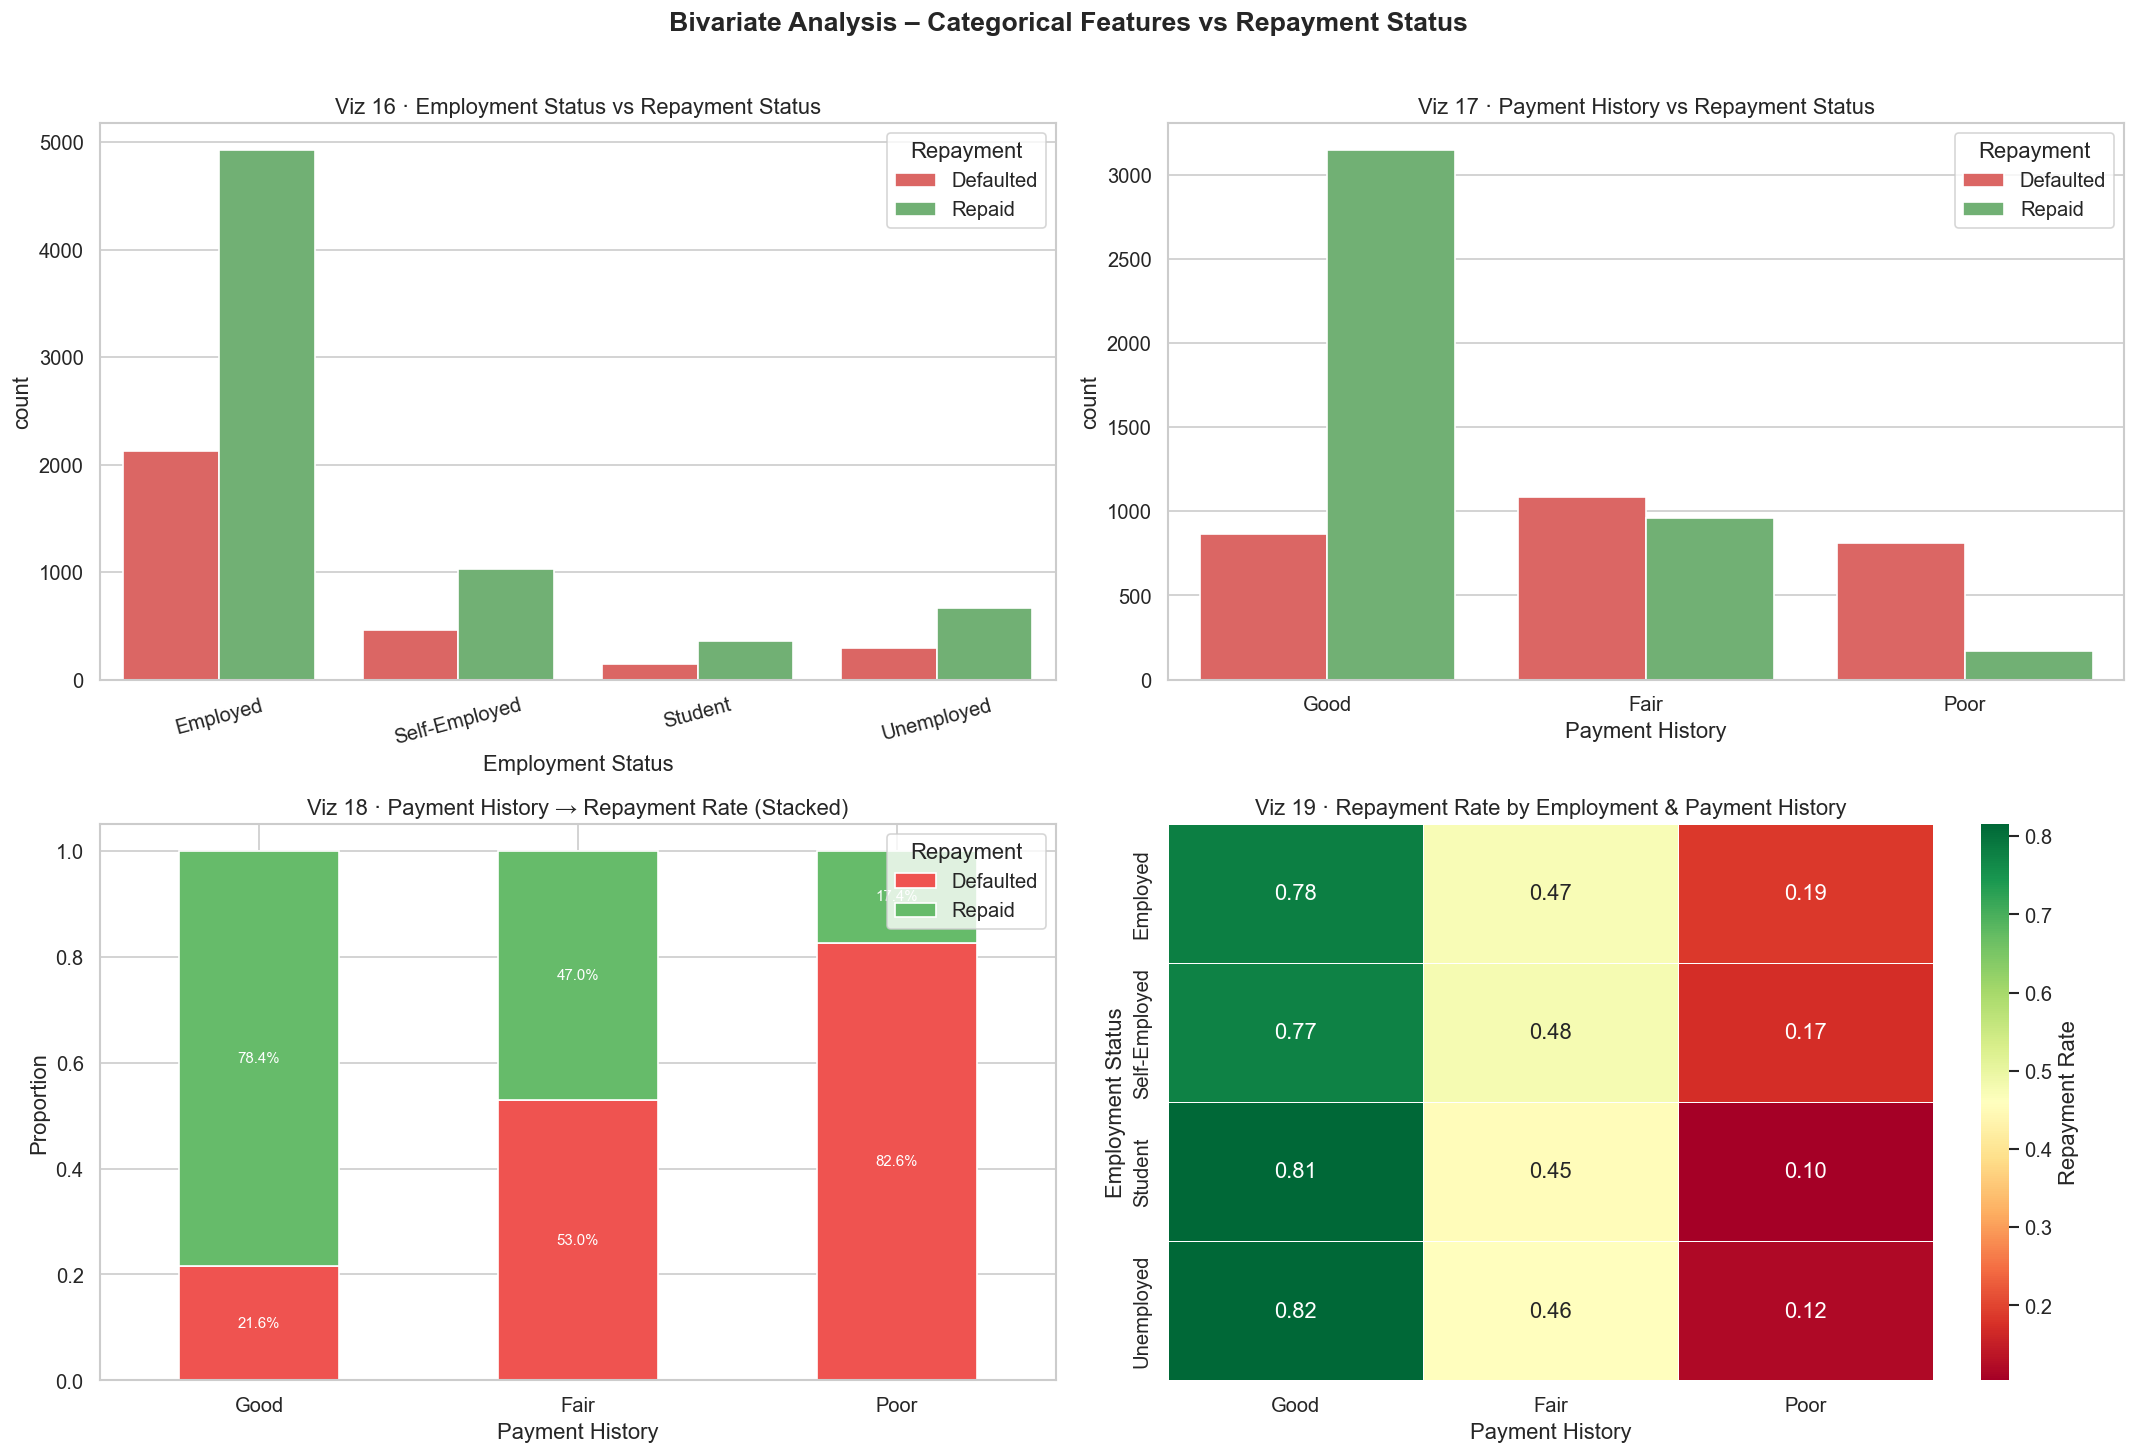

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Bivariate Analysis – Categorical Features vs Repayment Status",
             fontsize=16, fontweight="bold", y=1.01)

# Viz 16 – Employment_Status vs Repayment grouped countplot
sns.countplot(data=df_raw, x="Employment_Status", hue="Repayment_Label",
              palette={"Defaulted": "#EF5350", "Repaid": "#66BB6A"}, ax=axes[0, 0])
axes[0, 0].set_title("Viz 16 · Employment Status vs Repayment Status")
axes[0, 0].set_xlabel("Employment Status")
axes[0, 0].legend(title="Repayment")
axes[0, 0].tick_params(axis="x", rotation=15)

# Viz 17 – Payment_History vs Repayment grouped countplot
ph_order = ["Good", "Fair", "Poor"]
sns.countplot(data=df_raw, x="Payment_History", hue="Repayment_Label",
              order=ph_order, palette={"Defaulted": "#EF5350", "Repaid": "#66BB6A"}, ax=axes[0, 1])
axes[0, 1].set_title("Viz 17 · Payment History vs Repayment Status")
axes[0, 1].set_xlabel("Payment History")
axes[0, 1].legend(title="Repayment")

# Viz 18 – Stacked bar: Payment_History repayment rate
ph_repay = df_raw.groupby("Payment_History")["Repayment_Status"].value_counts(normalize=True).unstack()
ph_repay.columns = ["Defaulted", "Repaid"]
ph_repay = ph_repay.reindex(ph_order)
ph_repay.plot(kind="bar", stacked=True, color=["#EF5350", "#66BB6A"], ax=axes[1, 0], edgecolor="white")
axes[1, 0].set_title("Viz 18 · Payment History → Repayment Rate (Stacked)")
axes[1, 0].set_xlabel("Payment History")
axes[1, 0].set_ylabel("Proportion")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(title="Repayment", loc="upper right")
for bar in axes[1, 0].patches:
    h = bar.get_height()
    if h > 0.04:
        axes[1, 0].text(bar.get_x() + bar.get_width() / 2,
                        bar.get_y() + h / 2,
                        f"{h:.1%}", ha="center", va="center", color="white", fontsize=9)

# Viz 19 – Heatmap: repayment rate by Employment_Status × Payment_History
pivot = df_raw.pivot_table(values="Repayment_Status",
                            index="Employment_Status",
                            columns="Payment_History",
                            aggfunc="mean")
pivot = pivot[ph_order] if all(c in pivot.columns for c in ph_order) else pivot
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, ax=axes[1, 1], cbar_kws={"label": "Repayment Rate"})
axes[1, 1].set_title("Viz 19 · Repayment Rate by Employment & Payment History")
axes[1, 1].set_xlabel("Payment History")
axes[1, 1].set_ylabel("Employment Status")

plt.tight_layout()
plt.show()

## 8. Correlation Analysis
**Visualizations 20–21**

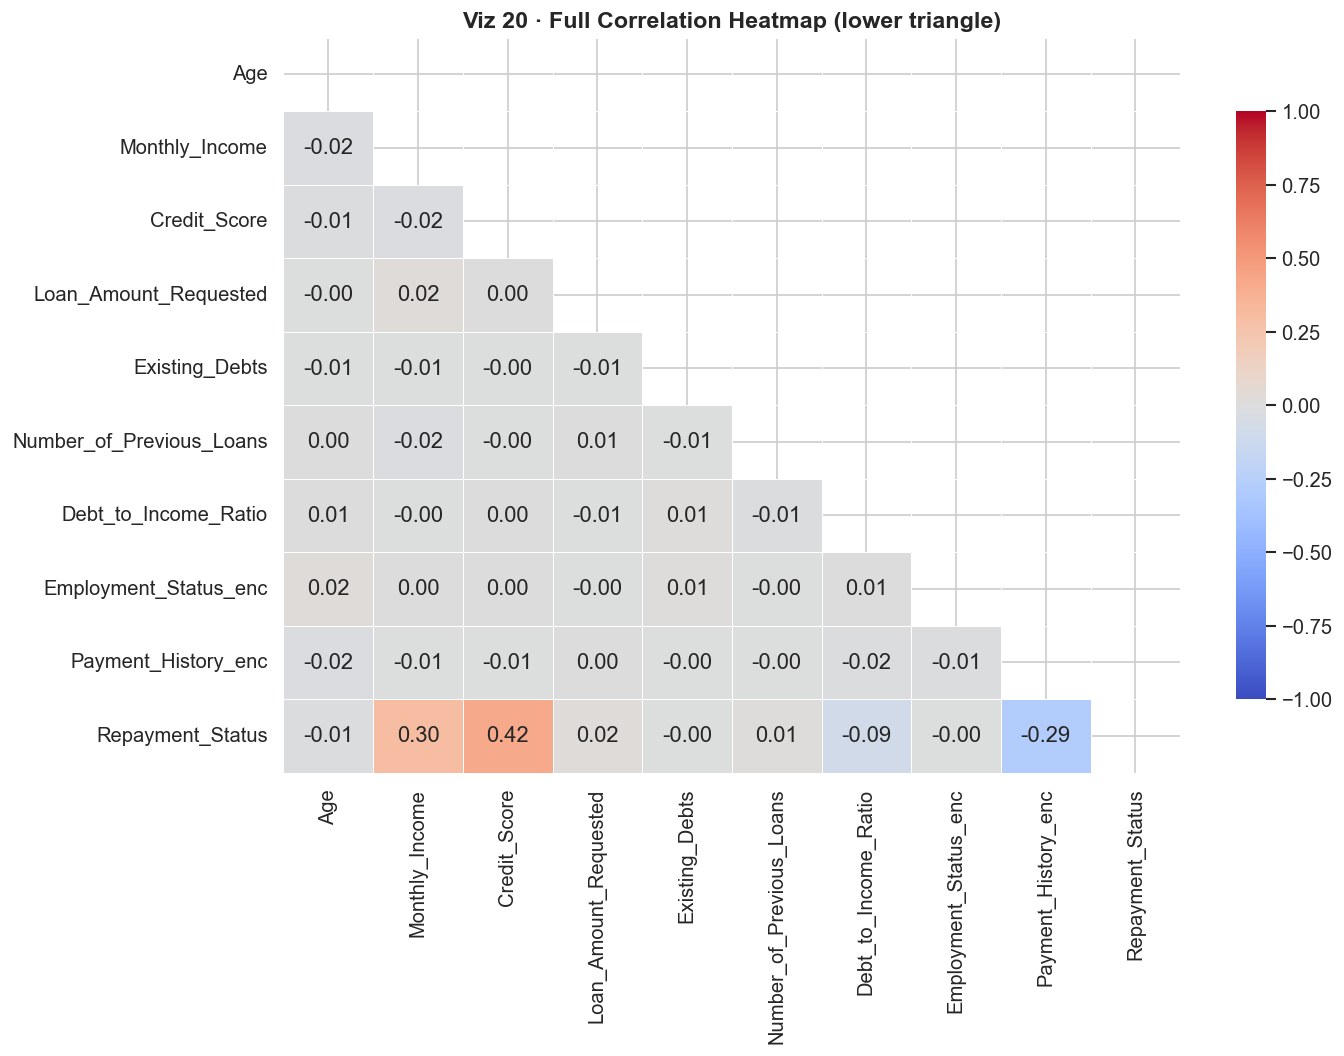

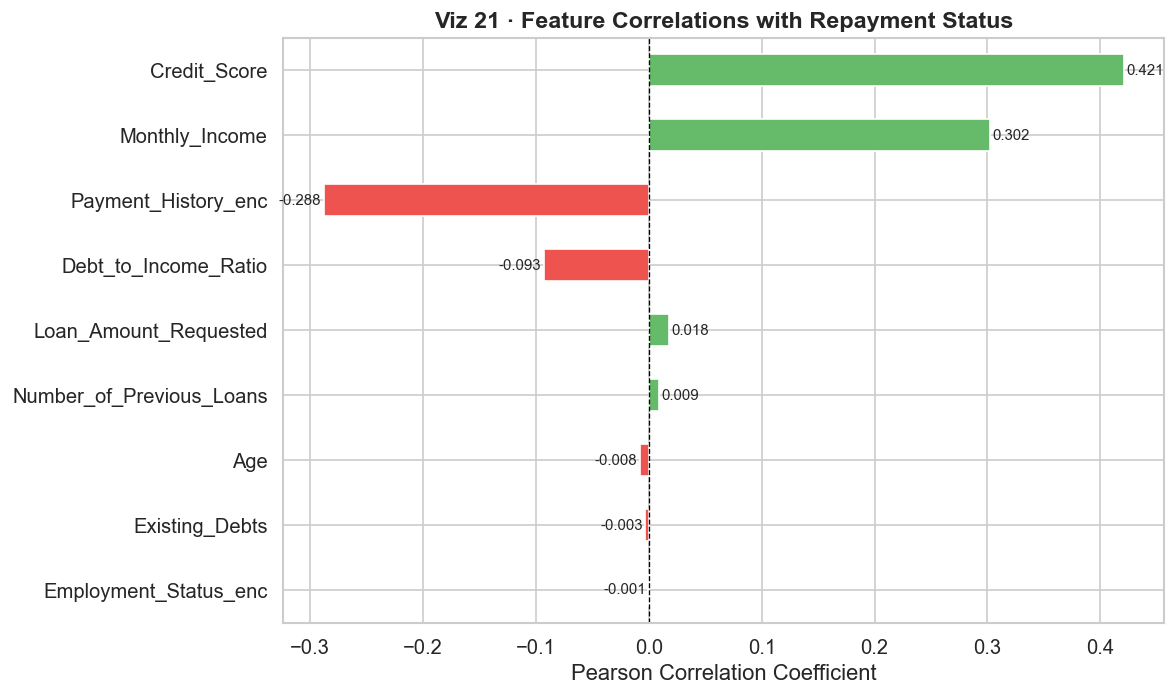

In [8]:
num_cols = ["Age", "Monthly_Income", "Credit_Score", "Loan_Amount_Requested",
            "Existing_Debts", "Number_of_Previous_Loans", "Debt_to_Income_Ratio",
            "Employment_Status_enc", "Payment_History_enc", "Repayment_Status"]

corr_matrix = df[num_cols].corr()

# Viz 20 – Full correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Viz 20 · Full Correlation Heatmap (lower triangle)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Viz 21 – Feature correlations with Repayment_Status (bar chart)
target_corr = corr_matrix["Repayment_Status"].drop("Repayment_Status").sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#EF5350" if v < 0 else "#66BB6A" for v in target_corr]
target_corr.plot(kind="barh", color=colors, edgecolor="white", ax=ax)
ax.set_title("Viz 21 · Feature Correlations with Repayment Status", fontsize=14, fontweight="bold")
ax.set_xlabel("Pearson Correlation Coefficient")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(ax.patches, target_corr):
    ax.text(bar.get_width() + (0.002 if val >= 0 else -0.002),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Distribution Analysis by Employment Status
**Visualizations 22–23**

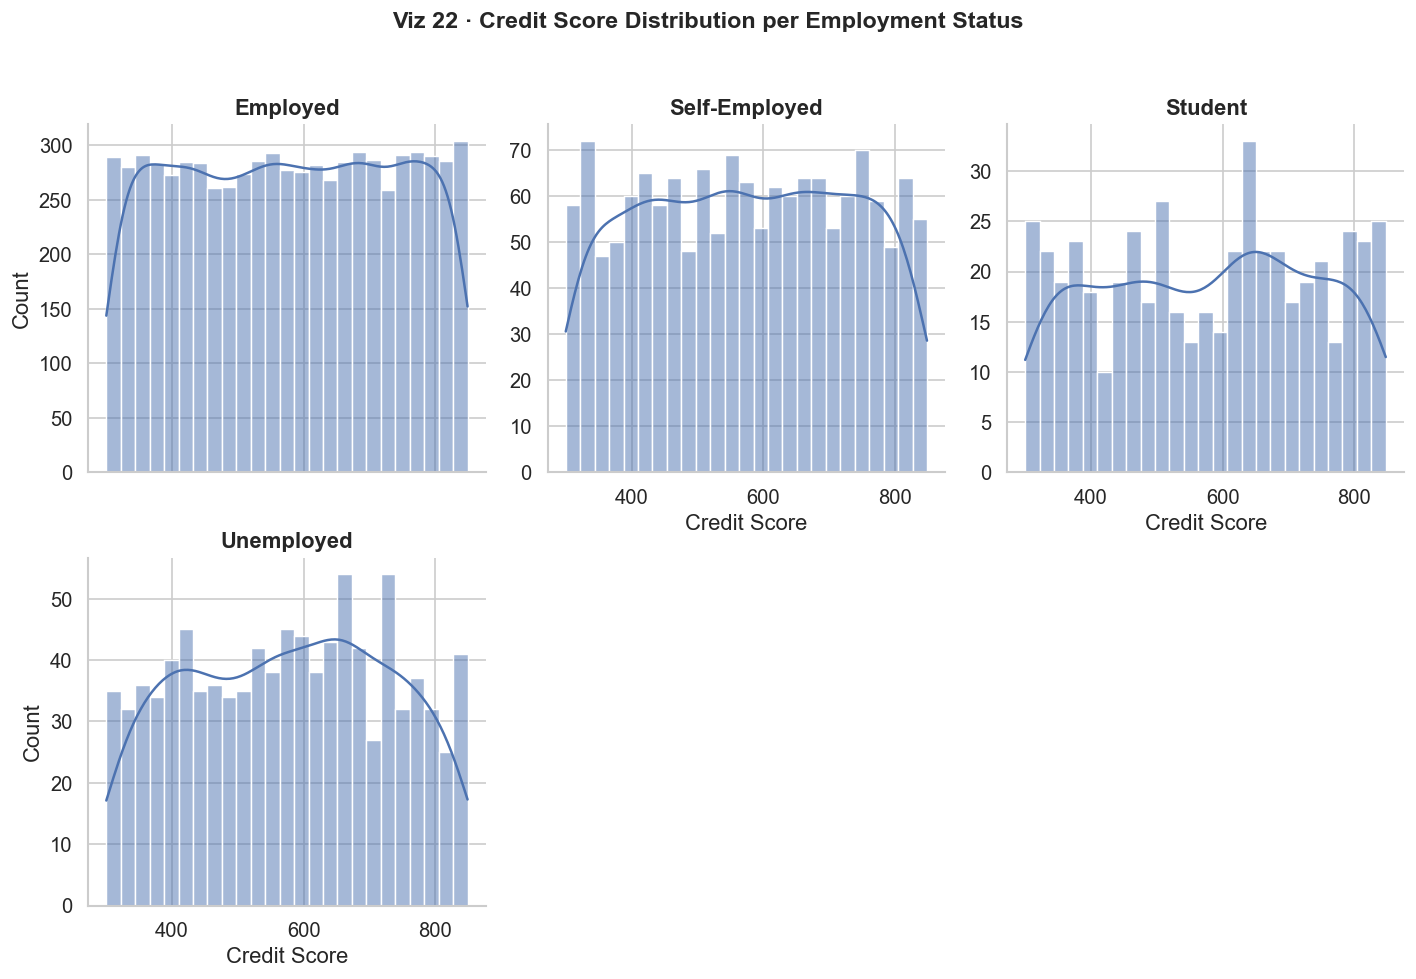

In [9]:
# Viz 22 – FacetGrid: Credit_Score distribution per Employment_Status
g = sns.FacetGrid(df_raw, col="Employment_Status", col_wrap=3, height=4, sharey=False,
                  palette="Set2")
g.map(sns.histplot, "Credit_Score", bins=25, kde=True, color="#4C72B0")
g.set_titles(col_template="{col_name}", fontweight="bold")
g.set_axis_labels("Credit Score", "Count")
g.figure.suptitle("Viz 22 · Credit Score Distribution per Employment Status",
                  fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

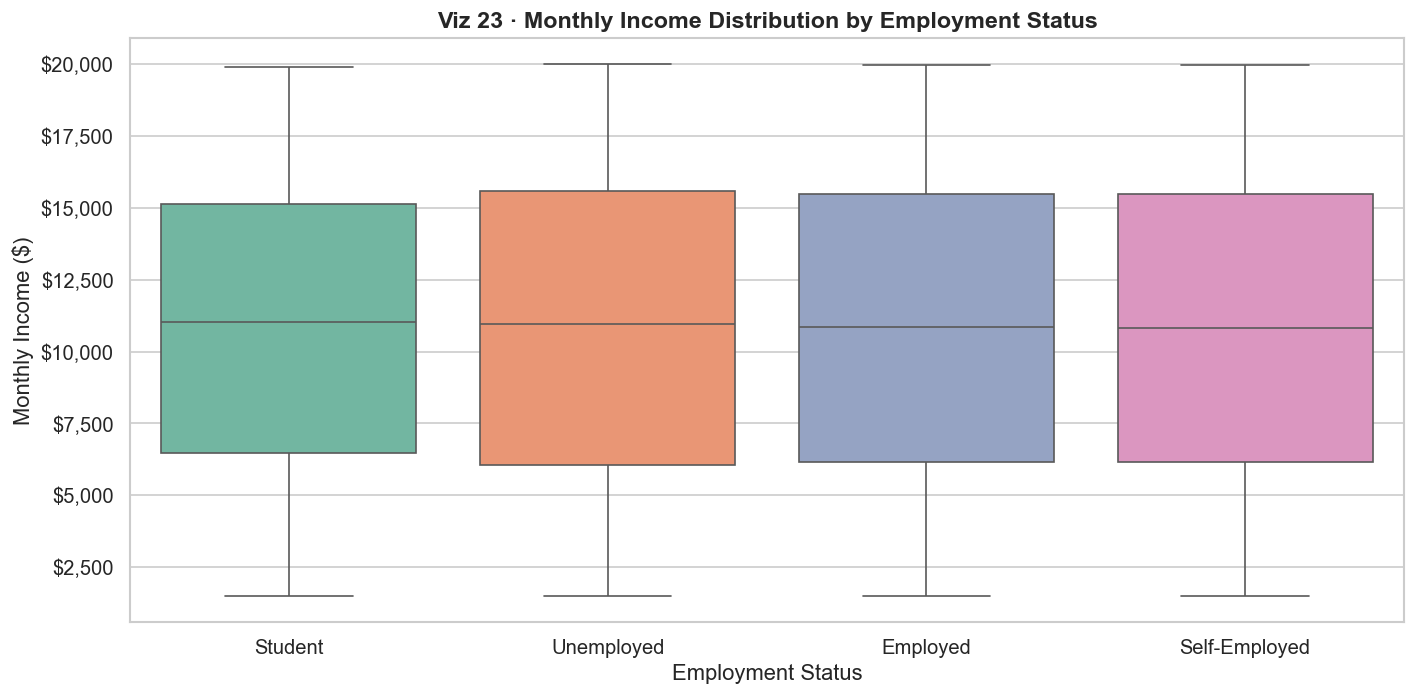

In [10]:
# Viz 23 – Boxplot grid: Monthly_Income across Employment_Status
fig, ax = plt.subplots(figsize=(12, 6))
emp_order_box = df_raw.groupby("Employment_Status")["Monthly_Income"].median().sort_values(ascending=False).index
sns.boxplot(data=df_raw, x="Employment_Status", y="Monthly_Income",
            order=emp_order_box, palette="Set2", ax=ax)
ax.set_title("Viz 23 · Monthly Income Distribution by Employment Status",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Employment Status")
ax.set_ylabel("Monthly Income ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## 10. Advanced Multivariate Visualizations
**Visualizations 24–25**

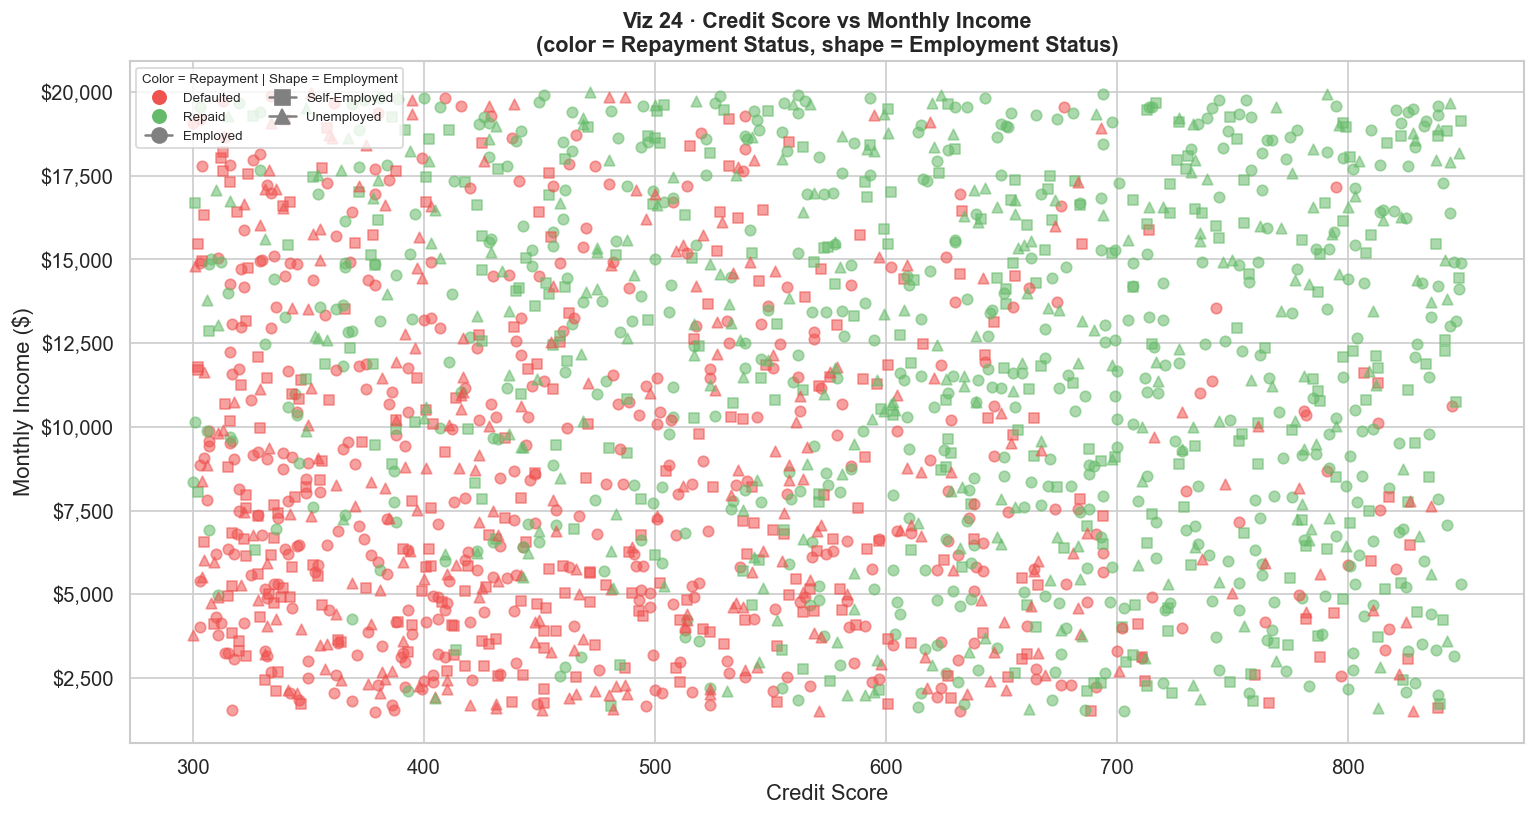

In [11]:
# Viz 24 – Scatter: Credit_Score vs Monthly_Income, color=Repayment, style=Employment_Status
fig, ax = plt.subplots(figsize=(13, 7))
markers = {"Employed": "o", "Self-Employed": "s", "Unemployed": "^",
           "Part-Time": "D", "Freelancer": "P"}
palette_24 = {"Defaulted": "#EF5350", "Repaid": "#66BB6A"}

for emp, emp_grp in df_raw.groupby("Employment_Status"):
    m = markers.get(emp, "o")
    for repay, r_grp in emp_grp.groupby("Repayment_Label"):
        sample = r_grp.sample(min(250, len(r_grp)), random_state=42)
        ax.scatter(sample["Credit_Score"], sample["Monthly_Income"],
                   color=palette_24[repay], marker=m, alpha=0.55, s=40,
                   label=f"{emp} / {repay}" if repay == "Defaulted" else "_nolegend_")

# Build legend manually
from matplotlib.lines import Line2D
color_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=l)
                 for l, c in palette_24.items()]
shape_handles = [Line2D([0], [0], marker=m, color="grey", markersize=9, label=e)
                 for e, m in markers.items() if e in df_raw["Employment_Status"].unique()]
ax.legend(handles=color_handles + shape_handles, title="Color = Repayment | Shape = Employment",
          fontsize=8, title_fontsize=8, loc="upper left", ncol=2)

ax.set_title("Viz 24 · Credit Score vs Monthly Income\n(color = Repayment Status, shape = Employment Status)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Credit Score")
ax.set_ylabel("Monthly Income ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

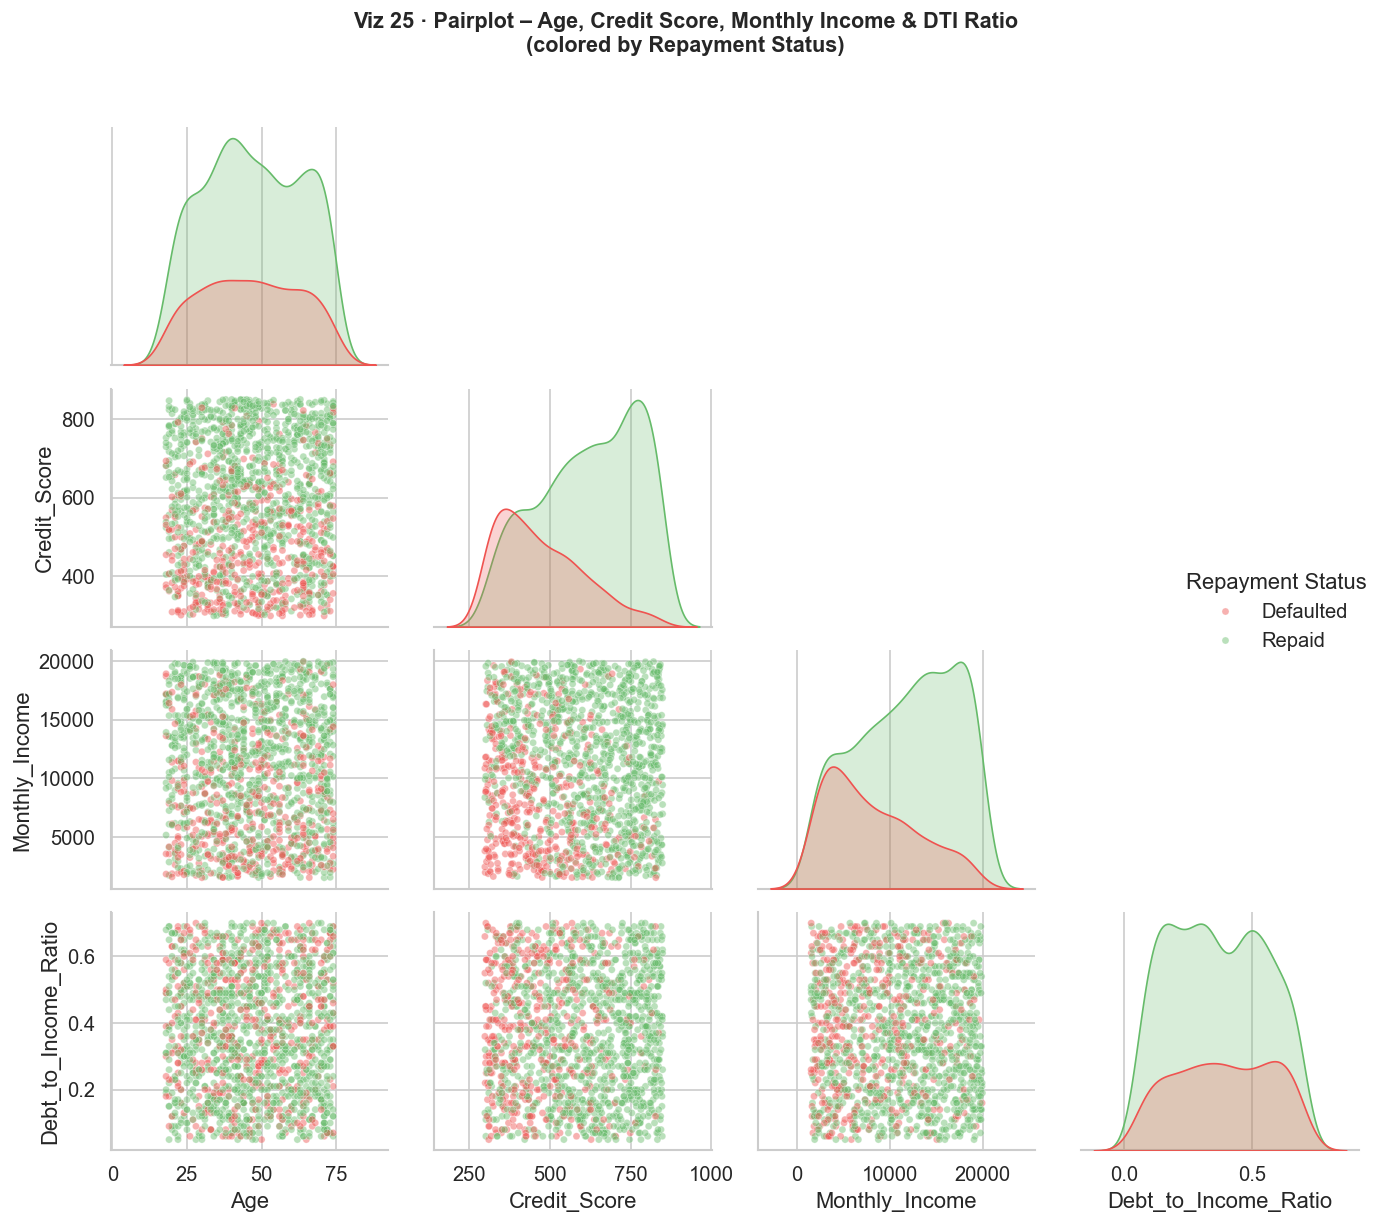

In [12]:
# Viz 25 – Pairplot of key numerical features, hued by Repayment_Status
pair_cols = ["Age", "Credit_Score", "Monthly_Income", "Debt_to_Income_Ratio", "Repayment_Label"]
pair_df = df_raw[pair_cols].sample(min(1500, len(df_raw)), random_state=42)

pair_grid = sns.pairplot(pair_df, hue="Repayment_Label",
                         palette={"Defaulted": "#EF5350", "Repaid": "#66BB6A"},
                         plot_kws=dict(alpha=0.45, s=18),
                         diag_kind="kde", corner=True)
pair_grid.figure.suptitle("Viz 25 · Pairplot – Age, Credit Score, Monthly Income & DTI Ratio\n(colored by Repayment Status)",
                           y=1.02, fontsize=13, fontweight="bold")
pair_grid._legend.set_title("Repayment Status")
plt.tight_layout()
plt.show()